<a href="https://colab.research.google.com/github/mamunh9/Autonomous-Systems-Lab/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 05: Support Vector Machine Fundamentals

## Learning objectives

After completing this lab, you should be able to:

- formulate a simple classification problem,
- explain the idea of a separating hyperplane,
- describe margin and support vectors,
- train an SVM with scikit-learn,
- compare training and test performance,
- interpret a confusion matrix,
- explain the role of the parameter $C$,
- compare a linear kernel and an RBF kernel,
- perform a small independent SVM experiment.

## Why this lab?

Before applying SVMs to line following in truck platooning, you should first understand how an SVM behaves on simple data. This lab focuses on the algorithmic and scientific basics. The following application lab will transfer these ideas to sensor-based line following.

## References

1. Cortes, C., Vapnik, V. (1995). *Support-vector networks*. Machine Learning, 20, 273–297.  
2. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
3. Hastie, T., Tibshirani, R., Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.  
4. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly.  
5. scikit-learn documentation: Support Vector Machines, https://scikit-learn.org/stable/modules/svm.html  
6. scikit-learn API reference: `sklearn.svm.SVC`, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html  

## 1. Workflow


1. **Define the problem** — What should be predicted?
2. **Define the dataset** — What are samples, features, and labels?
3. **Split the data** — Which data is used for training and testing?
4. **Train the model** — Which model and parameters are used?
5. **Evaluate the model** — Which metrics are used?
6. **Interpret the result** — What do the numbers mean?
7. **Discuss limitations** — What assumptions restrict the result?



## 2. Classification problem

In classification, the model predicts a discrete class label.

A dataset consists of samples:

$$
D = \{(x_1,y_1), (x_2,y_2), \ldots, (x_n,y_n)\}
$$

where $x_i \in \mathbb{R}^d$ is a feature vector and $y_i$ is the class label.

In this first lab, we use a two-dimensional binary classification problem:

$$
y_i \in \{0,1\}
$$

Using two features makes the data and the decision boundary easy to visualize.

## 3. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


## 4. Create a simple linearly separable dataset

We first create a synthetic dataset with two classes.

In [2]:
X, y = make_blobs(
    n_samples=120,
    centers=2,
    cluster_std=1.2,
    random_state=42
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (120, 2)
Shape of y: (120,)


### Task 5A.1: Interpret the dataset

Answer:

1. How many samples are in the dataset?
2. How many features does each sample have?
3. How many classes exist?
4. Why is a two-dimensional dataset useful for learning SVM basics?

1. 120 samples
2. 2 features
3. 2 classes
4. we can see the decision boundary, helps understand concepts visually.

## 5. Visualize the data

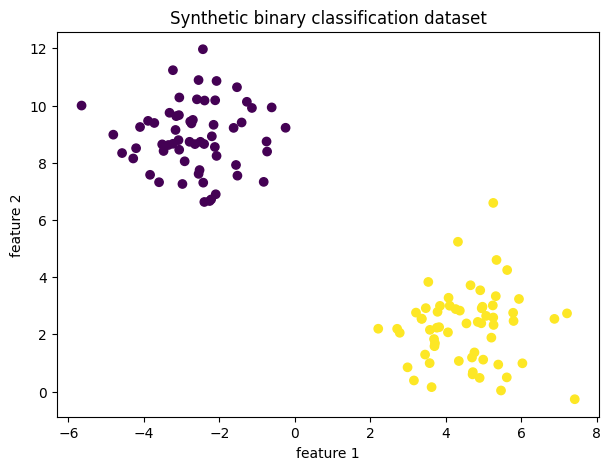

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Synthetic binary classification dataset")
plt.show()

### Task 5A.2: Visual interpretation

Answer:

1. Are the classes visually separable?
2. Would a straight line be a plausible decision boundary?
3. Are there samples close to the possible boundary?

1. yes
2. yes
3. yes

## 6. Mathematical idea: separating hyperplane

For binary classification, a linear SVM tries to find a separating hyperplane. In two dimensions, this hyperplane is a line:

$$
w^T x + b = 0
$$

where $w$ is the weight vector, $x$ is the input vector, and $b$ is the bias term.

The predicted class depends on which side of the hyperplane the sample lies. In the binary mathematical formulation, labels are often written as:

$$
y_i \in \{-1,+1\}
$$

and the prediction is:

$$
\hat{y} = \operatorname{sign}(w^T x + b)
$$

scikit-learn can use labels such as `0` and `1`; internally, the algorithm handles the classification problem.

## 7. Margin and support vectors

The SVM does not only search for any separating boundary. It searches for a boundary with a large **margin**.

The margin is the distance between the decision boundary and the closest training samples. The closest samples are called **support vectors**. They are important because they determine the final position of the decision boundary.

A larger margin is often associated with better generalization.

## 8. Train/test split

The training data is used to fit the model. The test data is used to estimate performance on unseen samples.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 90
Test samples: 30


### Task 5A.3: Explain the split

Answer:

1. Why do we use a train/test split?
2. What does the test set approximate?
3. Why is `stratify=y` useful?

1. This helps us check if the model can generalize to new, unseen data.
2. The test set simulates real-world unseen data.
3. stratify=y ensures that the class distribution stays the same in both sets.

## Scientific note: feature scaling and SVMs

Support Vector Machines are sensitive to the scale of input features.

The reason is that SVMs are geometric classifiers. They depend on:

- distances between samples,
- the margin,
- the orientation of the separating hyperplane,
- kernel values.

If one feature has much larger numerical values than another feature, it may dominate the distance calculation and therefore dominate the decision boundary.

Example:

- feature 1: sensor intensity in range $[0,1]$
- feature 2: velocity in range $[0,100]$

Without scaling, the velocity feature may influence the SVM more strongly only because its numerical range is larger.

A common solution is **standardization**:

$$
z = \frac{x - \mu}{\sigma}
$$

where:

- $x$ is the original feature value,
- $\mu$ is the mean of the feature,
- $\sigma$ is the standard deviation of the feature,
- $z$ is the standardized value.

After standardization, each feature has approximately mean $0$ and standard deviation $1$.

## Scientific note: avoiding data leakage

Feature scaling must be learned only from the training data.

Correct principle:

$$
\text{fit scaler only on } X_{\text{train}}
$$

Then apply the same transformation to both training and test data.

If the scaler is fitted before the train/test split, information from the test set leaks into the training process.
This would make the evaluation scientifically invalid.

A clean solution is to use a scikit-learn `Pipeline`:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(...))
])
```

The pipeline ensures that scaling and model training are handled consistently.

## 9. Train a linear SVM

We train a linear SVM using scikit-learn. The important method is:

```python
model.fit(X_train, y_train)
```

This means the model learns from labeled training samples.

In [4]:
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

svm_linear.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(kernel='linear'))])

## 10. Evaluate the model

In [5]:
y_pred = svm_linear.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", accuracy)

Test accuracy: 1.0


In [6]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print()
print("Classification report:")
print(classification_report(y_test, y_pred))

Confusion matrix:
[[15  0]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Task 5A.4: Interpret the evaluation

Answer:

1. What does accuracy measure?
2. What does the confusion matrix show?
3. Did the model make errors?
4. Why is it not enough to only report training accuracy?

1. Accuracy measures the proportion of correct predictions made by the model out of all predictions.
2. The confusion matrix shows what kinds of mistakes the model is making.
3. Yes, the model make errors.
4. Because a high training accuracy does not guarantee good real-world performance and sometimes the model fail on new data.

## 11. Inspect support vectors

scikit-learn stores support vectors in `model.support_vectors_` and the number of support vectors per class in `model.n_support_`.

In [ ]:
svm_model = svm_linear.named_steps["svm"]

print("Support vectors per class:", svm_model.n_support_)
print("Total number of support vectors:", len(svm_model.support_vectors_))

Support vectors per class: [1 2]
Total number of support vectors: 3


### Task 5A.5: Interpret support vectors

Answer:

1. What are support vectors?
2. Why are they important?
3. What could it mean if an SVM uses many support vectors?

1. Support vectors are the specific data points from the training set that lie closest to the decision boundary.
2. Because the SVM model depends only on these points not the entire dataset.
3. It may mean the data is not clearly separable,the model is more complex and sensitive to many points or there may be noise in the dataset.

## 12. Visualize decision boundary and support vectors

The following helper function visualizes data points, the decision boundary, and support vectors.

In [10]:
def plot_svm_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y)

    # If a pipeline is used, the SVM stores support vectors in the scaled feature space.
    # For visualization, we transform them back to the original feature space.
    if hasattr(model, "named_steps") and "scaler" in model.named_steps and "svm" in model.named_steps:
        support_vectors_scaled = model.named_steps["svm"].support_vectors_
        support_vectors_original = model.named_steps["scaler"].inverse_transform(support_vectors_scaled)
    else:
        support_vectors_original = model.support_vectors_

    plt.scatter(
        support_vectors_original[:, 0],
        support_vectors_original[:, 1],
        s=120,
        facecolors="none",
        edgecolors="black",
        label="support vectors"
    )

    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

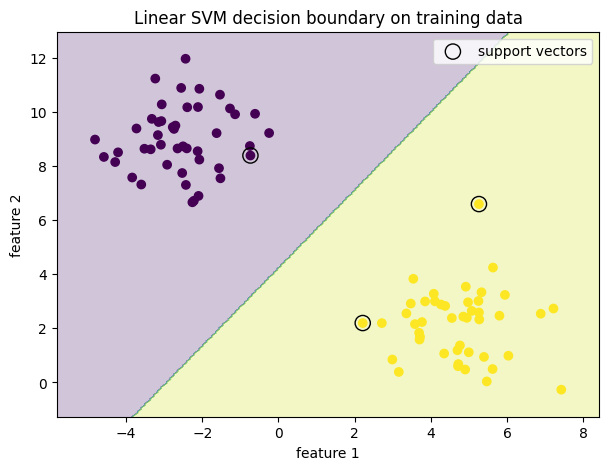

In [11]:
plot_svm_decision_boundary(svm_linear, X_train, y_train, "Linear SVM decision boundary on training data")

### Task 5A.6: Visual interpretation

Answer:

1. Where are the support vectors located?
2. Does the decision boundary separate the classes well?
3. Which samples seem difficult to classify?

1. The support vectors are the points highlighted with circles in the plot.
2. Yes, the decision boundary separates the two classes quite well.
3. The difficult samples are the ones closest to the decision boundary specifically, the support vectors themselves.

## 13. Soft-margin SVM and the parameter C

Real data is often noisy. A soft-margin SVM allows some classification errors.

$$
\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

subject to:

$$
y_i(w^T x_i + b) \geq 1 - \xi_i
$$

and:

$$
\xi_i \geq 0
$$

The parameter $C$ controls the trade-off:

- small $C$: wider margin, more tolerance for errors,
- large $C$: fewer training errors, narrower margin, higher overfitting risk.

## 14. Experiment: influence of C

In [12]:
C_values = [0.01, 0.1, 1, 10, 100]

results = []

for C in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C))
    ])
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    n_support = len(model.named_steps["svm"].support_vectors_)

    results.append([C, train_accuracy, test_accuracy, n_support])

results_df = pd.DataFrame(
    results,
    columns=["C", "train_accuracy", "test_accuracy", "number_of_support_vectors"]
)

results_df

,C,train_accuracy,test_accuracy,number_of_support_vectors
0,0.01,1.0,1.0,60
1,0.10,1.0,1.0,12
2,1.00,1.0,1.0,3
3,10.00,1.0,1.0,3
4,100.00,1.0,1.0,3


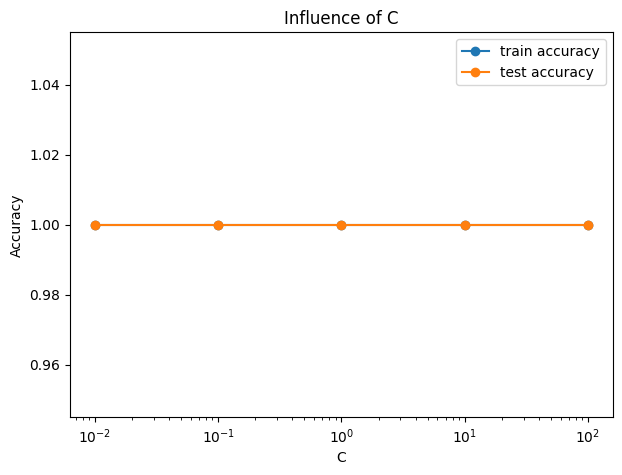

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(results_df["C"], results_df["train_accuracy"], marker="o", label="train accuracy")
plt.plot(results_df["C"], results_df["test_accuracy"], marker="o", label="test accuracy")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Influence of C")
plt.legend()
plt.show()

### Task 5A.7: Interpret the C experiment

Answer:

1. Does increasing $C$ always improve test accuracy?
2. What happens to the number of support vectors?
3. Which value of $C$ would you choose and why?

1. No. Increasing C does not always improve test accuracy.
2. Small C: more support vectors. Model allows more margin violations, more points influence the boundary.
Large C: fewer support vectors. Model focuses on correctly classifying points, boundary depends on fewer critical points.
3. I would choose the C where test accuracy is highest and the model is not overly complex.

## 15. Kernels and nonlinear classification

A linear SVM can only create a linear decision boundary. Some datasets are not linearly separable. For such cases, SVMs can use kernels.

The radial basis function kernel is:

$$
K(x,x') = \exp(-\gamma \|x-x'\|^2)
$$

The parameter $\gamma$ controls how local the influence of a training sample is.

## 16. Nonlinear example: moons dataset

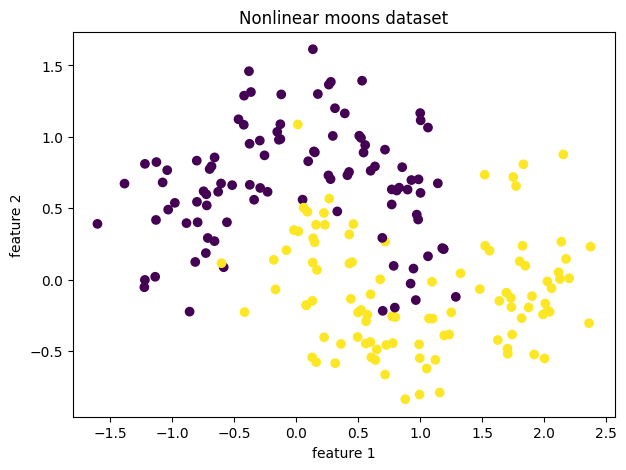

In [ ]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.25, random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Nonlinear moons dataset")
plt.show()

### Task 5A.8: Interpret the nonlinear data

Answer:

1. Can a straight line separate the classes well?
2. Why might a nonlinear kernel be useful here?

1. No. A straight line cannot separate the classes well in this dataset.
2. A nonlinear kernel is useful because it allows the SVM to create a curved decision boundary instead of a straight line and capture the complex structure of the data.

## 17. Compare linear and RBF SVM

In [ ]:
linear_moon = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons,
    test_size=0.25,
    random_state=42,
    stratify=y_moons
)
print("Training samples:", X_train_m.shape[0])
print("Test samples:", X_test_m.shape[0])
linear_moon.fit(X_train_m, y_train_m)

rbf_moon = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])
rbf_moon.fit(X_train_m, y_train_m)

print("Linear SVM test accuracy:", linear_moon.score(X_test_m, y_test_m))
print("RBF SVM test accuracy:", rbf_moon.score(X_test_m, y_test_m))

Training samples: 150
Test samples: 50
Linear SVM test accuracy: 0.88
RBF SVM test accuracy: 0.92


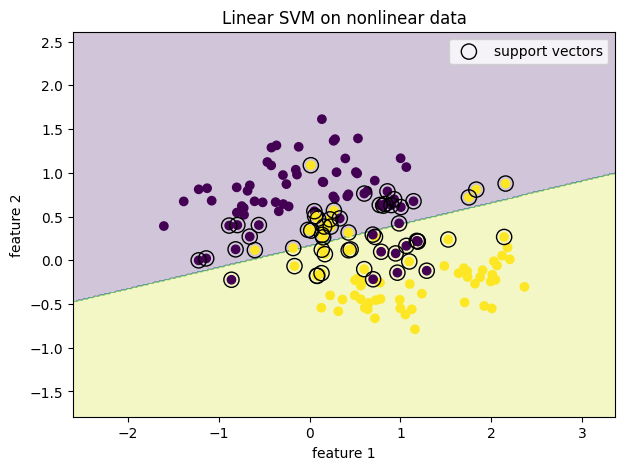

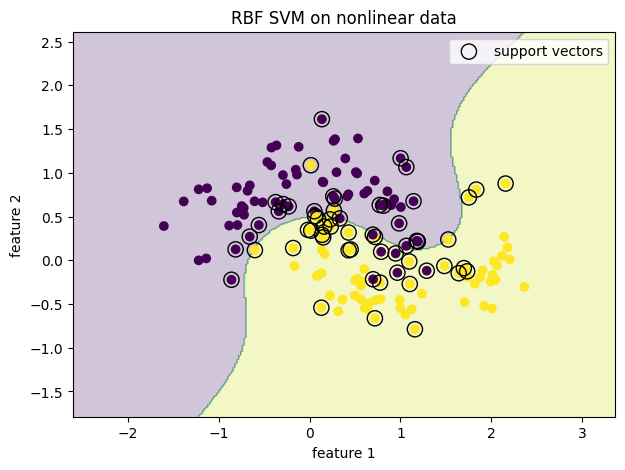

In [ ]:
plot_svm_decision_boundary(linear_moon, X_train_m, y_train_m, "Linear SVM on nonlinear data")
plot_svm_decision_boundary(rbf_moon, X_train_m, y_train_m, "RBF SVM on nonlinear data")

### Task 5A.9: Compare kernels

Answer:

1. Which model works better on the moons dataset?
2. How do the decision boundaries differ?
3. What is the risk of very flexible nonlinear boundaries?

1. The RBF (nonlinear) SVM works better.Because it follows the curved structure of the data and separates the two classes much more accurately.
2. Linear SVM: Produces a straight line, cannot capture the curved pattern
RBF SVM: Produces a curved, flexible boundary and separates the classes much more effectively.
3. It can become too complex and overfitting. Means it memorizes training data and performance on new data may decrease.

## 18. Independent realization task

Now perform your own small SVM experiment.

### Requirements

Use the moons dataset and investigate the influence of the RBF parameter $\gamma$.

1. Create a moons dataset with `n_samples=250`, `noise=0.30`, `random_state=7`.
2. Split the data into training and test data.
3. Train RBF SVM models with `gamma_values = [0.01, 0.1, 1, 10, 100]`.
4. For each $\gamma$, report training accuracy, test accuracy, and number of support vectors.
6. Visualize the decision boundary for the smallest, a medium, and the largest $\gamma$.
7. Write a short interpretation.

In [14]:
# TODO: implement the independent realization task
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=250, noise=0.30, random_state=7)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=7
)

gamma_values = [0.01, 0.1, 1, 10, 100]

results = []

for gamma in gamma_values:
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    n_sv = model.n_support_.sum()

    results.append((gamma, train_acc, test_acc, n_sv))

print("Gamma | Train Acc | Test Acc | #Support Vectors")
for r in results:
    print(f"{r[0]:>5} | {r[1]:.3f}     | {r[2]:.3f}    | {r[3]}")

Gamma | Train Acc | Test Acc | #Support Vectors
 0.01 | 0.811     | 0.800    | 132
  0.1 | 0.834     | 0.800    | 86
    1 | 0.937     | 0.853    | 59
   10 | 0.954     | 0.880    | 92
  100 | 0.983     | 0.853    | 161


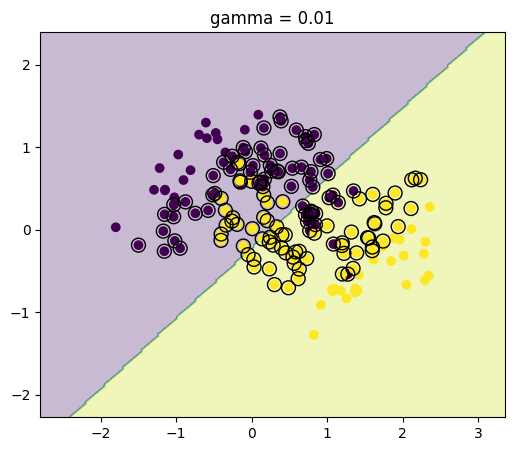

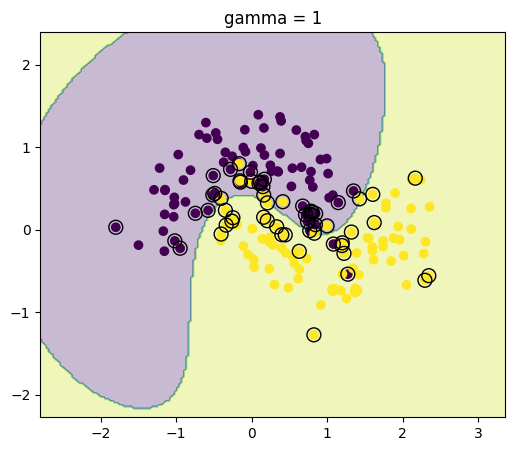

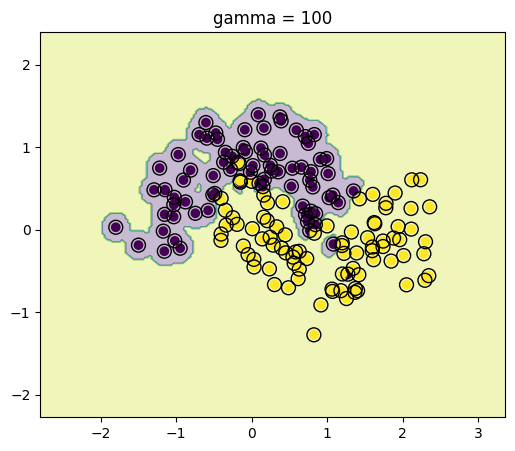

In [15]:
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(6,5))

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.scatter(model.support_vectors_[:,0],
                model.support_vectors_[:,1],
                s=100, facecolors='none', edgecolors='k')

    plt.title(title)
    plt.show()

# Plot for small, medium, large gamma
for gamma in [0.01, 1, 100]:
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X_train, y_train, f"gamma = {gamma}")

## 19. Limitations

This lab uses synthetic two-dimensional datasets.

Limitations:

- The data is simpler than real sensor data.
- The features do not represent real vehicle states.
- The visual decision boundary is only possible because the data is two-dimensional.
- Real ML systems require careful preprocessing, validation, and robustness testing.
- Accuracy alone is not sufficient for safety-critical applications.

The purpose of this lab is to understand SVM fundamentals before applying SVMs to line following.

## Summary

You learned:

- SVMs are margin-based classifiers,
- support vectors determine the decision boundary,
- $C$ controls the soft-margin trade-off,
- kernels enable nonlinear decision boundaries,
- train/test split estimates generalization,
- confusion matrices help analyze errors.

Next step: apply these ideas to a simplified line-following problem in truck platooning.